# 13_Logistic Regression

In [1]:
from google.colab import drive

# Google Drive를 Colab에 Mount
drive.mount('/content/drive')

# 강의용 Data가 저장된 Folder

data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

Mounted at /content/drive


# Logistic Regression

이번 강의에서는 두 Class 중 하나를 예측하는 Classification Problem을 다룬다.

예를 들어 다음과 같은 문제들이 있다.

- Email → Spam / Normal
- Customer → Purchase / No Purchase
- Loan Applicant → Default / No Default
- Machine → Failure / Normal

이러한 문제에서는 Output이 연속적인 값이 아니라 두 개의 Class 중 하나이다.

$$
y \in \{0,1\}
$$

이러한 문제를 Binary Classification이라고 한다.

## A Simple Binary Classification Problem

먼저 하나의 Input Variable $x$를 이용하여 Class를 예측하는 간단한 문제부터 살펴보자.

Input:

$$
x
$$

Output:

$$
y \in \{0,1\}
$$

주어진 $x$를 이용하여 $y=0$ 또는 $y=1$을 예측하는 것이 목적이다.

먼저 Data를 확인해 보자.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1D Binary Classification Data
df = pd.read_csv(
    data_path + "logistic_data1.csv"
)

display(df.head())

print("Shape:", df.shape)
print(df["y"].value_counts())

,x,y
0,-1.254599,1
1,4.507143,1
2,2.319939,1
3,0.986585,1
4,-3.439814,0


Shape: (200, 2)
y
0    103
1     97
Name: count, dtype: int64


## Observe the Data

$x$와 $y$의 관계를 직접 그려 보자.

Output은 연속적인 값이 아니라

$$
0 \quad \text{or} \quad 1
$$

중 하나이다.

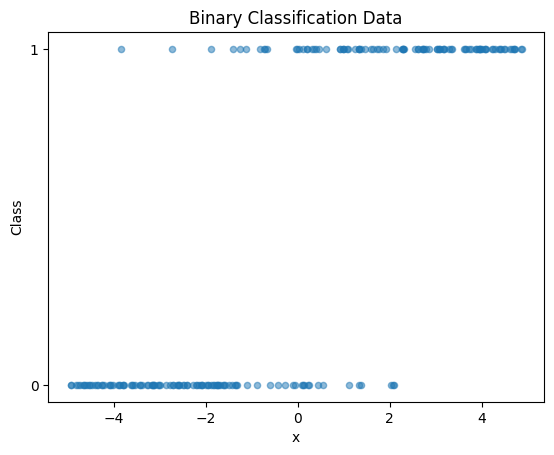

In [6]:
# Binary Data 시각화
plt.scatter(
    df["x"],
    df["y"],
    alpha=0.5,
    s=20
)

plt.xlabel("x")
plt.ylabel("Class")
plt.yticks([0, 1])
plt.title("Binary Classification Data")

plt.show()

## Can We Use Linear Regression?

지금까지 Numerical Value를 예측하기 위해 Linear Regression을 사용하였다.

그렇다면 Binary Classification에서도 다음 Model을 사용할 수 있을까?

$$
\hat{y}=wx+b
$$

실제로 Linear Regression을 적용해 보자.

In [7]:
from sklearn.linear_model import LinearRegression

# Input과 Output
X = df[["x"]]
y = df["y"]

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)

# Prediction
linear_pred = linear_model.predict(X)

print("Weight:", linear_model.coef_[0])
print("Bias:", linear_model.intercept_)

Weight: 0.13364453623692157
Bias: 0.506374795377646


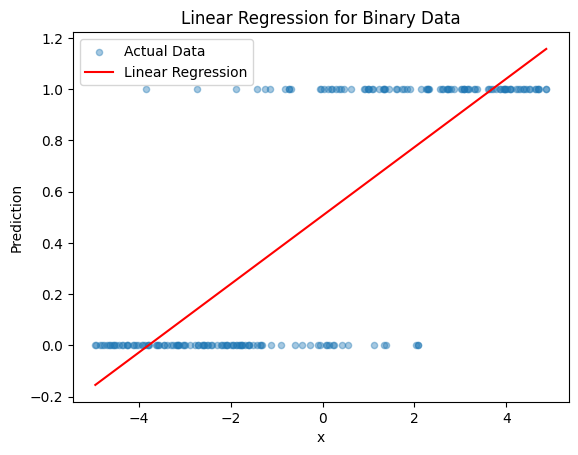

In [10]:
# Regression Line을 그리기 위한 Input
x_curve = np.linspace(
    df["x"].min(),
    df["x"].max(),
    300
)

X_curve = pd.DataFrame({
    "x": x_curve
})

y_curve = linear_model.predict(X_curve)

# Data와 Linear Regression 결과 비교
plt.scatter(
    df["x"],
    df["y"],
    alpha=0.4,
    s=20,
    label="Actual Data"
)

plt.plot(
    x_curve,
    y_curve,
    label="Linear Regression",
    color='r'
)

plt.xlabel("x")
plt.ylabel("Prediction")
plt.title("Linear Regression for Binary Data")
plt.legend()

plt.show()

## Problem with Linear Regression

Linear Regression은 Binary Classification Data에도 계산 자체는 가능하다.

그러나 Prediction은 다음 범위를 가질 수 있다.

$$
-\infty < \hat{y} < \infty
$$

따라서

$$
\hat{y}<0
$$

또는

$$
\hat{y}>1
$$

과 같은 값도 나올 수 있다.

하지만 Class 1에 속할 Probability를 표현하려면 값은 다음 범위에 있어야 한다.

$$
0 \le P(y=1|x) \le 1
$$

따라서 Linear Regression의 Output을 0과 1 사이의 값으로 변환할 방법이 필요하다.

## Classification as Probability

Binary Classification을 다음과 같이 생각할 수 있다.

주어진 $x$에 대해

$$
P(y=1|x)
$$

를 먼저 구한다.

예를 들어

$$
P(y=1|x)=0.9
$$

라면 Class 1일 가능성이 높다고 판단할 수 있다.

반대로

$$
P(y=1|x)=0.1
$$

이라면 Class 0일 가능성이 높다고 판단할 수 있다.

즉,

> Input → Probability → Class

의 순서로 Classification을 수행할 수 있다.

## Sigmoid Function

Linear Model의 결과를 0과 1 사이로 변환하기 위해 Sigmoid Function을 사용할 수 있다.

$$
\sigma(z)
=
\frac{1}{1+e^{-z}}
$$

여기서

$$
z=wx+b
$$

이다.

Sigmoid Function의 Output은 항상 다음 범위에 있다.

$$
0<\sigma(z)<1
$$

In [ ]:
# Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)

plt.plot(
    z,
    sigmoid(z)
)

plt.axhline(
    0.5,
    linestyle="--"
)

plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")

plt.show()

## Logistic Regression

Logistic Regression은 먼저 Linear Combination을 계산한다.

$$
z=wx+b
$$

그리고 Sigmoid Function을 적용한다.

$$
P(y=1|x)
=
\frac{1}{1+e^{-(wx+b)}}
$$

따라서 Logistic Regression의 Output은 Class 자체가 아니라 먼저 Probability이다.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model
model = LogisticRegression()

# Training
model.fit(
    X_train,
    y_train
)

print("Weight:", model.coef_[0][0])
print("Bias:", model.intercept_[0])

Weight: 1.1591305963776672
Bias: 0.027641984460332916


## Probability Prediction

Logistic Regression에서는 `predict_proba()`를 이용하여 각 Class에 속할 Probability를 확인할 수 있다.

Binary Classification에서는 각 Sample에 대해

$$
P(y=0|x)
$$

와

$$
P(y=1|x)
$$

를 얻는다.

두 Probability의 합은 1이다.

In [13]:
# Probability Prediction
prob = model.predict_proba(X_test)

result = pd.DataFrame({
    "x": X_test["x"].values,
    "Actual": y_test.values,
    "P(y=0)": prob[:, 0],
    "P(y=1)": prob[:, 1]
})

display(result.head(10))

,x,Actual,P(y=0),P(y=1)
0,-0.062044,0,0.511067,0.488933
1,-3.165955,0,0.974472,0.025528
2,1.075449,1,0.218534,0.781466
3,-2.623625,0,0.953179,0.046821
4,-4.930479,0,0.996623,0.003377
5,3.714606,1,0.012953,0.987047
6,4.868869,1,0.003432,0.996568
7,1.775644,1,0.110480,0.889520
8,1.451728,1,0.153114,0.846886
9,1.625223,1,0.128814,0.871186


## Probability Curve

Training된 Logistic Regression Model이 만든 Probability를 그림으로 확인해 보자.

이 Curve는

$$
P(y=1|x)
$$

를 나타낸다.

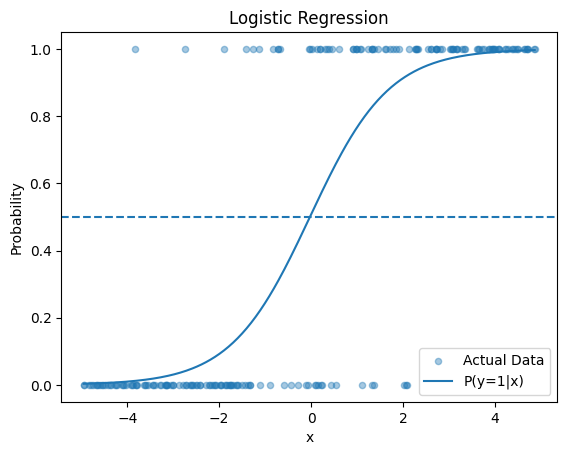

In [14]:
# Logistic Probability Curve
x_curve = np.linspace(
    df["x"].min(),
    df["x"].max(),
    300
)

X_curve = pd.DataFrame({
    "x": x_curve
})

p_curve = model.predict_proba(
    X_curve
)[:, 1]

plt.scatter(
    df["x"],
    df["y"],
    alpha=0.4,
    s=20,
    label="Actual Data"
)

plt.plot(
    x_curve,
    p_curve,
    label="P(y=1|x)"
)

plt.axhline(
    0.5,
    linestyle="--"
)

plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Logistic Regression")
plt.legend()

plt.show()

## From Probability to Class

Probability를 최종 Class로 변환하기 위해 Threshold를 사용한다.

일반적으로 Threshold를 0.5로 사용한다.

$$
P(y=1|x)\ge0.5
\quad\Rightarrow\quad
\hat{y}=1
$$

$$
P(y=1|x)<0.5
\quad\Rightarrow\quad
\hat{y}=0
$$

In [15]:
# Final Class Prediction
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": prob[:, 1],
    "Prediction": y_pred
})

display(comparison.head(15))

,Actual,Probability,Prediction
0,0,0.488933,0
1,0,0.025528,0
2,1,0.781466,1
3,0,0.046821,0
4,0,0.003377,0
5,1,0.987047,1
6,1,0.996568,1
7,1,0.889520,1
8,1,0.846886,1
9,1,0.871186,1


## Logistic Regression with Two Features

이제 두 개의 Input Features를 사용해 보자.

$$
X=(x_1,x_2)
$$

Linear Combination은

$$
z=w_1x_1+w_2x_2+b
$$

이고,

Class 1의 Probability는

$$
P(y=1|X)
=
\frac{1}
{1+e^{-(w_1x_1+w_2x_2+b)}}
$$

이다.

먼저 Data를 확인해 보자.

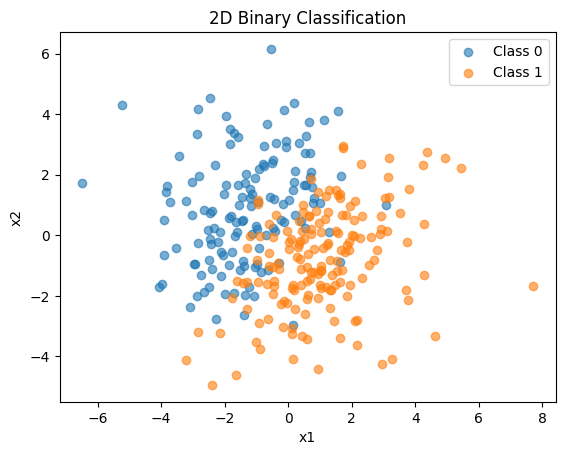

In [17]:
# 2D Binary Classification Data
df2 = pd.read_csv(
    data_path + "logistic_data2.csv"
)

# Class별로 시각화
plt.scatter(
    df2[df2["y"] == 0]["x1"],
    df2[df2["y"] == 0]["x2"],
    label="Class 0",
    alpha=0.6
)

plt.scatter(
    df2[df2["y"] == 1]["x1"],
    df2[df2["y"] == 1]["x2"],
    label="Class 1",
    alpha=0.6
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Binary Classification")
plt.legend()

plt.show()

## Decision Boundary

Logistic Regression에서 Probability가 0.5가 되는 지점은

$$
z=0
$$

이다.

두 Features를 사용하는 경우

$$
w_1x_1+w_2x_2+b=0
$$

이 된다.

이를 정리하면

$$
x_2
=
-\frac{w_1x_1+b}{w_2}
$$

가 된다.

따라서 2차원 Feature Space에서는 Decision Boundary가 하나의 Straight Line이 된다.

w1: 1.618182294903797
w2: -1.1546910441062472
b : 0.4095800320761845


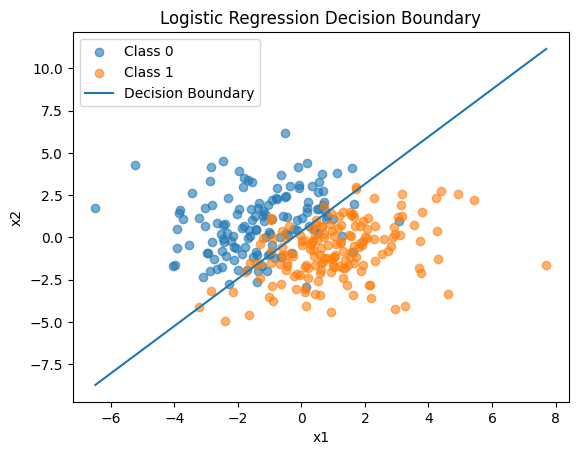

In [18]:
# Input / Output
X2 = df2[["x1", "x2"]]
y2 = df2["y"]

# Logistic Regression
model2 = LogisticRegression()
model2.fit(X2, y2)

# Parameter
w1 = model2.coef_[0][0]
w2 = model2.coef_[0][1]
b = model2.intercept_[0]

print("w1:", w1)
print("w2:", w2)
print("b :", b)

# Decision Boundary
x1_line = np.linspace(
    df2["x1"].min(),
    df2["x1"].max(),
    200
)

x2_line = -(w1 * x1_line + b) / w2

# Data
plt.scatter(
    df2[df2["y"] == 0]["x1"],
    df2[df2["y"] == 0]["x2"],
    label="Class 0",
    alpha=0.6
)

plt.scatter(
    df2[df2["y"] == 1]["x1"],
    df2[df2["y"] == 1]["x2"],
    label="Class 1",
    alpha=0.6
)

# Decision Boundary
plt.plot(
    x1_line,
    x2_line,
    label="Decision Boundary"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()

plt.show()

# Input / Output
X2 = df2[["x1", "x2"]]
y2 = df2["y"]

# Logistic Regression
model2 = LogisticRegression()
model2.fit(X2, y2)

# Parameter
w1 = model2.coef_[0][0]
w2 = model2.coef_[0][1]
b = model2.intercept_[0]

print("w1:", w1)
print("w2:", w2)
print("b :", b)

# Decision Boundary
x1_line = np.linspace(
    df2["x1"].min(),
    df2["x1"].max(),
    200
)

x2_line = -(w1 * x1_line + b) / w2

# Data
plt.scatter(
    df2[df2["y"] == 0]["x1"],
    df2[df2["y"] == 0]["x2"],
    label="Class 0",
    alpha=0.6
)

plt.scatter(
    df2[df2["y"] == 1]["x1"],
    df2[df2["y"] == 1]["x2"],
    label="Class 1",
    alpha=0.6
)

# Decision Boundary
plt.plot(
    x1_line,
    x2_line,
    label="Decision Boundary"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()

plt.show()

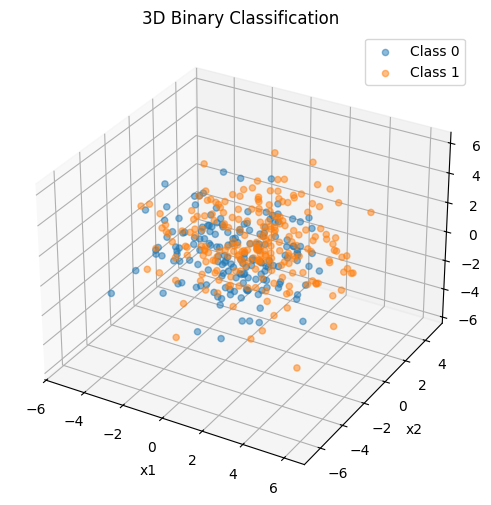

In [20]:
# 3D Data
df3 = pd.read_csv(
    data_path + "logistic_data4.csv"
)

fig = plt.figure(
    figsize=(8, 6)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

# Class 0
ax.scatter(
    df3[df3["y"] == 0]["x1"],
    df3[df3["y"] == 0]["x2"],
    df3[df3["y"] == 0]["x3"],
    label="Class 0",
    alpha=0.5
)

# Class 1
ax.scatter(
    df3[df3["y"] == 1]["x1"],
    df3[df3["y"] == 1]["x2"],
    df3[df3["y"] == 1]["x3"],
    label="Class 1",
    alpha=0.5
)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")

ax.set_title(
    "3D Binary Classification"
)

ax.legend()

plt.show()

## Beyond Three Dimensions

세 개의 Features까지는 3D Plot으로 어느 정도 Visualization할 수 있다.

하지만 Features가 네 개 이상이면 사람이 직접 공간을 Visualization하기 어렵다.

그러나 Logistic Regression의 계산에는 문제가 없다.

네 개의 Features라면

$$
z
=
w_1x_1+w_2x_2+w_3x_3+w_4x_4+b
$$

이고,

$$
P(y=1|X)=\sigma(z)
$$

를 그대로 계산한다.

즉,

> Visualization이 어렵다는 것과 Machine Learning이 불가능하다는 것은 다른 문제이다.

## Summary

Logistic Regression은 Binary Classification을 위한 Machine Learning Method이다.

Linear Combination:

$$
z=w_1x_1+w_2x_2+\cdots+w_px_p+b
$$

Sigmoid Function:

$$
P(y=1|X)
=
\frac{1}{1+e^{-z}}
$$

Threshold:

$$
P(y=1|X)\ge0.5
\Rightarrow
\hat{y}=1
$$

$$
P(y=1|X)<0.5
\Rightarrow
\hat{y}=0
$$

Dimension에 따라 Decision Boundary는 다음과 같이 확장된다.

- 1 Feature → Point
- 2 Features → Line
- 3 Features → Plane
- Higher Dimensions → Hyperplane

전체 과정은 다음과 같다.

> Input → Linear Combination → Sigmoid → Probability → Threshold → Class

## Homework - Problem 13

`Input/logistic_data3.csv`를 이용하여 Logistic Regression을 수행한다.

다음 조건을 사용한다.

- Input Features: `x1`, `x2`
- Output: `y`
- `test_size=0.2`
- `random_state=42`

다음 질문에 답하시오.

- 학습된 `x1`의 Weight를 소수점 셋째 자리까지 적으시오.
- 학습된 `x2`의 Weight를 소수점 셋째 자리까지 적으시오.
- 학습된 Bias를 소수점 셋째 자리까지 적으시오.
- Test Data의 Accuracy를 소수점 셋째 자리까지 적으시오.
- Test Data의 첫 번째 Sample에 대한 $P(y=1|X)$를 소수점 셋째 자리까지 적으시오.
- 위 Probability를 Threshold 0.5를 사용하여 분류한 Class를 적으시오.

답만 제출하시오.